In [40]:
import pytest

In [1]:
# default code from transformers website
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-0.6B")
messages = [
    {"role": "user", "content": "Who are you?"},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

/Users/andrewkuang/Code/standard-kernel-takehome/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 5314.05it/s]


<think>
Okay, the user asked, "Who are you?" I need to respond appropriately. Let me start by acknowledging their question.

I should mention that I'm a language model, but I can


In [2]:
# take a look at this model's layers
print("QWEN model\n")
print(model)


print("\nUp proj")
proj = model.model.layers[0].mlp.up_proj
print(proj.weight.shape, proj.weight.dtype)

QWEN model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_att

In [3]:
import matplotlib.pyplot as plt
import torch

# first layer MLP layer up projection
W = model.model.layers[0].mlp.up_proj.weight.detach().float()
print(f"shape={tuple(W.shape)}, absmax={W.abs().max():.4f}, mean|w|={W.abs().mean():.4f}")
# 3072 rows - one for each output neuron
# 1024 cols - one for each input feature

shape=(3072, 1024), absmax=0.3750, mean|w|=0.0204


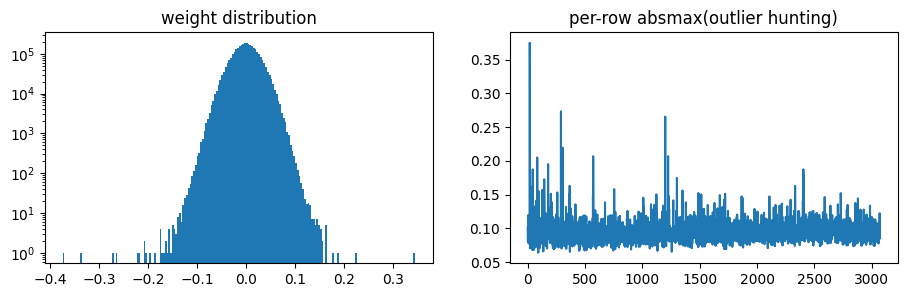

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(W.flatten().numpy(), bins = 200); ax[0].set_yscale("log")
ax[0].set_title("weight distribution")
ax[1].plot(W.abs().max(dim=1).values.numpy())
ax[1].set_title('per-row absmax(outlier hunting)')
plt.show()

## Demo of quantizing to e2m1

In [5]:
def e2m1_values():
    """SEEM layout with exponent bias = 1

    S     E    E      M
    |     |           |
    sign exponent mantissa

    """

    vals = []
    for code in range(16):
        sign = (code >> 3) & 1 # shifts right and then mask the last bit
        exp = (code >> 1) & 3 # shifts right 1 and mask to get lowest 2 bits
        mant = code & 1 # masks lowest bit of original

        if exp == 0: # subnormal: value = 0.5 * mant
            v = 0.5 * mant
        
        else: # normal: 2^(exp - 1) * (1 + 0.5 * mant)
            v = (2 ** (exp - 1)) * (1 + 0.5 * mant)
        
        vals.append(-v if sign else v)
    
    return vals

for code, v in enumerate(e2m1_values()):
    print(f"{code:04b} {v:+.2f}")

0000 +0.00
0001 +0.50
0010 +1.00
0011 +1.50
0100 +2.00
0101 +3.00
0110 +4.00
0111 +6.00
1000 -0.00
1001 -0.50
1010 -1.00
1011 -1.50
1100 -2.00
1101 -3.00
1110 -4.00
1111 -6.00


In [6]:
import numpy as np

fp4_levels = np.array(sorted(set(e2m1_values())))  # LUT of representable FP4 values
FP4_MAX = 6.0

def quantize_block_absmax(x, levels=fp4_levels, fp4_max=FP4_MAX):
    scale = np.abs(x).max() / fp4_max # stretch data into our FP4 grid
    if scale == 0: scale = 1.0
    scaled = x / scale # round each scaled value to nearest representable FP4 level
    idx = np.abs(scaled[:, None] - levels[None, :]).argmin(axis=1)
    return levels[idx], scale

block_32 = W[0, :32].numpy() 
q, s = quantize_block_absmax(block_32) # like a fake quantize and then unquantize
dq = q * s

print(f"original : {block_32[:8].round(3)}")
print(f"dequant  : {dq[:8].round(3)}")
print(f"MSE={((block_32-dq)**2).mean():.6f}  relMSE (quantization error)={((block_32-dq)**2).mean()/(block_32**2).mean():.4f}")



block_64 = W[0, :128].numpy() 
q, s = quantize_block_absmax(block_64) # like a fake quantize and then unquantize
dq = q * s

print(f"original : {block_64[:8].round(3)}")
print(f"dequant  : {dq[:8].round(3)}")
print(f"MSE={((block_64-dq)**2).mean():.6f}  relMSE (quantization error)={((block_64-dq)**2).mean()/(block_64**2).mean():.4f}")

original : [-0.042  0.    -0.001  0.013  0.027 -0.025 -0.001 -0.028]
dequant  : [-0.038  0.     0.     0.014  0.029 -0.029  0.    -0.029]
MSE=0.000008  relMSE (quantization error)=0.0099
original : [-0.042  0.    -0.001  0.013  0.027 -0.025 -0.001 -0.028]
dequant  : [-0.05   0.     0.     0.017  0.025 -0.025  0.    -0.025]
MSE=0.000009  relMSE (quantization error)=0.0136


some notes here:
- relMSE is a good normalized evaluation metric to see severity of quantize/dequantization error
- probably would be interesting to see *scaled* vs. the fp4 scale to see how each scaled weight becomes the rounding
-  try larger and larger blocks? to see howscale and relMSE will change
-  compare this to per-tensor scaling and compute avg MSE

**Idea: plotting scaled values against the fp4 scale to see rounding amt**

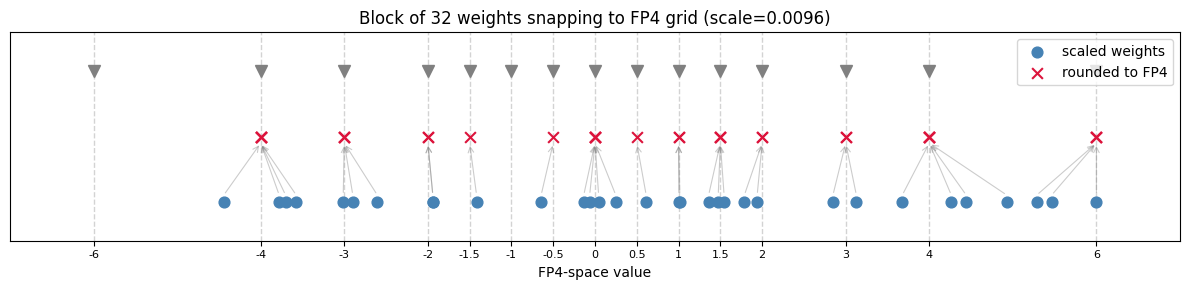

In [7]:
import matplotlib.pyplot as plt
import numpy as np

block = W[0, :32].numpy()
# block is (32, ) - original 32 raw float weights from our model
q, s = quantize_block_absmax(block)
scaled = block / s # so now scaled is between +6 and -6

fig, ax = plt.subplots(figsize=(12, 3))

# 1. draw the fp4 grid as verticle lines
for level in fp4_levels:
    ax.axvline(level, color='lightgray', linestyle='--', linewidth=1, zorder=1)

# 2. mark each FP4 level with a labeled tick on bottom
for level in fp4_levels:
    ax.plot(level, 1.0, marker='v', color='gray', markersize=8, zorder=2)

# 3. plot each of the  scaled weights as dots on the number line
ax.scatter(scaled, np.zeros_like(scaled),
           color='steelblue', s=60, zorder=3, label='scaled weights')

# 4. plot where each one rounded to
ax.scatter(q, np.full_like(q, 0.5),
           color='crimson', s=60, marker='x', zorder=3, label='rounded to FP4')

# 5. draw arrows from original scaled value to its rounded level
for orig, rounded in zip(scaled, q):
    ax.annotate('', xy=(rounded, 0.45), xytext=(orig, 0.05),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.4, lw=0.8))

ax.set_xlim(-7, 7)
ax.set_ylim(-0.3, 1.3)
ax.set_yticks([])
ax.set_xticks(fp4_levels)
ax.set_xticklabels([f'{v:g}' for v in fp4_levels], fontsize=8)
ax.set_xlabel('FP4-space value')
ax.set_title(f'Block of 32 weights snapping to FP4 grid (scale={s:.4f})')
ax.legend(loc='upper right')
ax.grid(False)
plt.tight_layout()
plt.show()

In [8]:
fp4_levels # just curious

array([-6. , -4. , -3. , -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,
        2. ,  3. ,  4. ,  6. ])

In [9]:
# 
def absmax_qdq(W_np, block_size, levels=fp4_levels, fp4_max=FP4_MAX):
    rows, K = W_np.shape # rows = 3072 output neurons in linear layer, k = 1024 input features per neuron
    nb = K // block_size
    Wb = W_np[:, :nb*block_size].reshape(rows, nb, block_size)
    s  = np.abs(Wb).max(-1, keepdims=True) / fp4_max
    s  = np.where(s == 0, 1.0, s)
    idx = np.abs((Wb / s)[..., None] - levels).argmin(-1)
    return (levels[idx] * s).reshape(rows, nb*block_size)

W_np = W.numpy()    
for bs in [16, 32, 64, 128, 256]:
    dq = absmax_qdq(W_np, bs)
    orig = W_np[:, :dq.shape[1]]
    rel = ((orig - dq)**2).mean() / (orig**2).mean()
    print(f"bs={bs:4d}  relMSE={rel:.4f}  scale overhead={32/bs:.2f} bits/wt (fp32 scales)")

bs=  16  relMSE=0.0088  scale overhead=2.00 bits/wt (fp32 scales)
bs=  32  relMSE=0.0102  scale overhead=1.00 bits/wt (fp32 scales)
bs=  64  relMSE=0.0112  scale overhead=0.50 bits/wt (fp32 scales)
bs= 128  relMSE=0.0120  scale overhead=0.25 bits/wt (fp32 scales)
bs= 256  relMSE=0.0127  scale overhead=0.12 bits/wt (fp32 scales)


In [34]:
import torch.nn as nn
import copy

class FakeQuantLinear(nn.Module):
    def __init__(self, linear, block_size=32):
        super().__init__()
        W = linear.weight.detach().float().cpu().numpy()
        # pad K to multiple of block_size, then trim back
        pad = (-W.shape[1]) % block_size
        Wp  = np.pad(W, ((0,0),(0,pad)))
        dq  = absmax_qdq(Wp, block_size)[:, :W.shape[1]]
        self.weight = nn.Parameter(
            torch.from_numpy(dq).to(linear.weight.dtype).to(linear.weight.device),
            requires_grad=False,
        )
        self.bias = linear.bias

    def forward(self, x):
        return nn.functional.linear(x, self.weight, self.bias)

# snapshot original generation for comparison
out_bf16 = model.generate(**inputs, max_new_tokens=40, do_sample=False)
print("BF16    :", tokenizer.decode(out_bf16[0][inputs["input_ids"].shape[-1]:]))

# swap just ONEE layer's up_proj
orig = model.model.layers[0].mlp.up_proj
model.model.layers[0].mlp.up_proj = FakeQuantLinear(orig, block_size=32)

out_fp4 = model.generate(**inputs, max_new_tokens=40, do_sample=False)
print("FP4 L0  :", tokenizer.decode(out_fp4[0][inputs["input_ids"].shape[-1]:]))

# restore
model.model.layers[0].mlp.up_proj = orig

BF16    : <think>
Okay, the user asked, "Who are you?" I need to respond appropriately. First, I should acknowledge their question. I can say something like, "Hello! I'm a language
FP4 L0  : <think>
Okay, the user asked, "Who are you?" I need to respond appropriately. First, I should acknowledge their question. I can say something like, "Hi! I'm a language


In [33]:
orig.zero_grad()

In [15]:
def swap_all(model, block_size, which):
    """which is a list like ['up_proj', 'gate_proj', 'down_proj', 'q_proj', ...]"""
    originals = {}
    for i, layer in enumerate(model.model.layers):
        for name in which:
            for parent_name in ['mlp', 'self_attn']:
                parent = getattr(layer, parent_name, None)
                if parent is not None and hasattr(parent, name):
                    mod = getattr(parent, name)
                    originals[(i, parent_name, name)] = mod
                    setattr(parent, name, FakeQuantLinear(mod, block_size))
    return originals

def restore(model, originals):
    for (i, p, n), mod in originals.items():
        setattr(getattr(model.model.layers[i], p), n, mod)

# try: all MLPs only
orig = swap_all(model, 32, ['up_proj', 'gate_proj', 'down_proj'])
out = model.generate(**inputs, max_new_tokens=40, do_sample=False)
print("all MLP fp4 :", tokenizer.decode(out[0][inputs["input_ids"].shape[-1]:]))
restore(model, orig)

# then: all attention only — often more sensitive
orig = swap_all(model, 32, ['q_proj', 'k_proj', 'v_proj', 'o_proj'])
out = model.generate(**inputs, max_new_tokens=40, do_sample=False)
print("all attn fp4:", tokenizer.decode(out[0][inputs["input_ids"].shape[-1]:]))
restore(model, orig)

all MLP fp4 : <think>
Okay, the user asked, "Who are you?" I need to respond appropriately. First, I should acknowledge their question and explain my role. I'll mention that I'm an AI assistant
all attn fp4: <think>
Okay, the user asked, "Who are you?" I need to respond in a way that's helpful and informative. Let me start by acknowledging their question. I should explain that I'm


# Packing and Unpacking

In [ ]:
def pack_fp4(codes: np.ndarray) -> np.ndarray:
    """codes: uint8 array of shape (..., N) with values in [0, 15].
       Returns: uint8 array of shape (..., ceil(N/2)) packing two 4-bit codes per byte."""
    
    

    
    

def unpack_fp4(packed: np.ndarray, n: int) -> np.ndarray:
    """Inverse of pack_fp4. n is the original (possibly odd) length along the last axis."""

In [7]:
def test_pack_fp4():
    N = 20
    
    # identity
    test = np.array([0, 1, 2, 15, 8, 7], dtype = np.uint8)
    for x, y in zip(test, pack_fp4(test)):
        assert x == y

    # identity
    test2 = np.random.randint(0, 16, size= N, dtype = np.uint8)
    for x, y in zip(test2, pack_fp4(test2)):
        assert x == y
    
    # output shape and dtype
    test3 = np.random.randint(0, 16, size= N, dtype = np.uint8)
    for i in test3:
        assert i.dtype == np.uint8

    # out-of-range inputs
    with pytest.raises(OverflowError):
        pack_fp4(np.ndarray([14, 15, 16], dtype = np.uint8))

        pack_fp4(np.ndarray([256, 267, 268], dtype = np.uint8))

    # batched input
    codes = np.array([
        [0, 1, 2, 3],
        [4, 5, 6, 7]],
        dtype = np.uint8
    )

    packed = pack_fp4(codes)
    print(packed)
